# Adult Income: Cleaning, EDA and Feature Engineering
**Name:** Akshat Shah  
**Date:** September 29, 2026

This project checks data quality, explores patterns in income, and creates features that could support a future classification model. No prediction model is required for this assignment.

In [2]:
from pathlib import Path
import sys
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.max_columns", 30)
OUTPUT_DIR = Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")

def save_chart(name):
    plt.tight_layout()
    plt.savefig(CHART_DIR / name, dpi=150, bbox_inches="tight")
    plt.show()

Python 3.13.15 | pandas 2.2.3 | numpy 2.1.3


## 1. Load and inspect the data

In [3]:
candidates = [Path("data/adult.csv"), Path("adult.csv"), Path("/content/adult.csv")]
if Path("/kaggle/input").exists():
    candidates += sorted(Path("/kaggle/input").rglob("adult.csv"))
data_path = next((p for p in candidates if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError("Download adult.csv from the linked Kaggle dataset and upload it or attach the dataset.")

raw = pd.read_csv(data_path)
print("Loaded:", data_path)
print("Shape:", raw.shape)
print("SHA256:", hashlib.sha256(data_path.read_bytes()).hexdigest())
display(raw.head())
df = raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_", regex=False)
df = df.rename(columns={"educational_num": "education_num", "gender": "sex"})
original_columns = df.columns.tolist()
numeric_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
categorical_cols = [c for c in df.columns if c not in numeric_cols]
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "unique_values": df.nunique(),
                      "initial_nulls": df.isna().sum()}))
display(df[numeric_cols].describe().round(2))

Loaded: adult.csv
Shape: (48842, 15)
SHA256: 1f13ee2bf9d7c66098429281ab91fa1b51cbabd3b805cc365b3c6b44491ea2c0


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


,dtype,unique_values,initial_nulls
age,int64,74,0
workclass,object,9,0
fnlwgt,int64,28523,0
education,object,16,0
education_num,int64,16,0
marital_status,object,7,0
occupation,object,15,0
relationship,object,6,0
race,object,5,0
sex,object,2,0


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


## 2. Clean missing values and duplicates

In [4]:
for col in categorical_cols:
    df[col] = df[col].astype("string").str.strip().replace({"?": pd.NA, "": pd.NA})
df["income"] = df["income"].str.rstrip(".")
missing_before = df.isna().sum()
missing_table = pd.DataFrame({"missing_count": missing_before,
                              "missing_percent": (missing_before / len(df) * 100).round(2)})
display(missing_table[missing_table.missing_count > 0])
rows_with_missing = int(df.isna().any(axis=1).sum())
duplicates_removed = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
missing_labels_removed = int(df["income"].isna().sum())
df = df.dropna(subset=["income"]).copy()
for col in categorical_cols:
    if col != "income":
        df[col] = df[col].fillna("Unknown")
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")
assert df[numeric_cols].notna().all().all(), "Inspect numeric missingness before continuing."
assert set(df["income"].unique()) == {"<=50K", ">50K"}
print("Rows with at least one missing value before cleaning:", rows_with_missing)
print("Exact duplicates removed:", duplicates_removed)
print("Missing income labels removed:", missing_labels_removed)
print("Remaining null values:", int(df.isna().sum().sum()))

,missing_count,missing_percent
workclass,2799,5.73
occupation,2809,5.75
native_country,857,1.75


Rows with at least one missing value before cleaning: 3620
Exact duplicates removed: 52
Missing income labels removed: 0
Remaining null values: 0


## 3. Inspect and handle outliers

In [5]:
invalid_rules = pd.DataFrame({
    "age_outside_17_100": ~df["age"].between(17, 100),
    "hours_outside_1_168": ~df["hours_per_week"].between(1, 168),
    "education_outside_1_16": ~df["education_num"].between(1, 16),
    "nonpositive_weight": df["fnlwgt"] <= 0,
    "negative_capital_gain": df["capital_gain"] < 0,
    "negative_capital_loss": df["capital_loss"] < 0,
})
display(invalid_rules.sum().rename("invalid_rows").to_frame())
invalid_mask = invalid_rules.any(axis=1)
invalid_removed = int(invalid_mask.sum())
df = df.loc[~invalid_mask].copy()
outlier_rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flag = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({"column": col, "min": df[col].min(), "max": df[col].max(),
                         "IQR": iqr, "lower_fence": lower, "upper_fence": upper,
                         "flagged_rows": int(flag.sum()), "flagged_percent": 100 * flag.mean()})
    if col in ["age", "hours_per_week"]:
        df[col + "_iqr_flag"] = flag.astype(int)
outlier_table = pd.DataFrame(outlier_rows).set_index("column")
display(outlier_table.round(2))
print("Invalid rows removed:", invalid_removed)
print("Clean rows:", len(df))
print("Plausible statistical extremes were retained.")
assert not df[original_columns].duplicated().any()
assert df.notna().all().all()
df["income_gt_50k"] = df["income"].eq(">50K").astype(int)
cleaning_audit = pd.DataFrame({"step": ["Original rows", "Duplicate rows removed",
    "Missing labels removed", "Invalid numeric rows removed", "Clean rows"],
    "count": [len(raw), duplicates_removed, missing_labels_removed, invalid_removed, len(df)]})
display(cleaning_audit)

,invalid_rows
age_outside_17_100,0
hours_outside_1_168,0
education_outside_1_16,0
nonpositive_weight,0
negative_capital_gain,0
negative_capital_loss,0


,min,max,IQR,lower_fence,upper_fence,flagged_rows,flagged_percent
column,,,,,,,
age,17,90,20.00,-2.00,78.00,215,0.44
fnlwgt,12285,1490400,120051.25,-62521.88,417683.12,1453,2.98
education_num,1,16,3.00,4.50,16.50,1787,3.66
capital_gain,0,99999,0.00,0.00,0.00,4035,8.27
capital_loss,0,4356,0.00,0.00,0.00,2282,4.68
hours_per_week,1,99,5.00,32.50,52.50,13486,27.64


Invalid rows removed: 0
Clean rows: 48790
Plausible statistical extremes were retained.


,step,count
0,Original rows,48842
1,Duplicate rows removed,52
2,Missing labels removed,0
3,Invalid numeric rows removed,0
4,Clean rows,48790


## 4. Exploratory data analysis

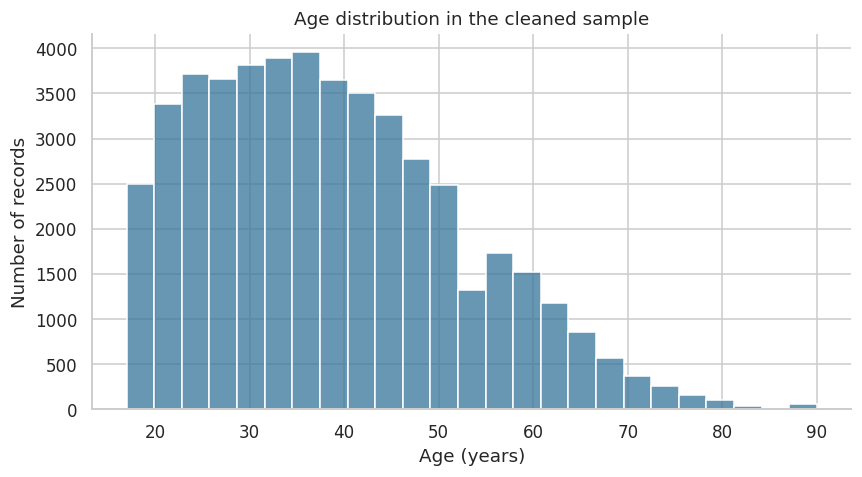

Median age: 37.0


In [6]:
# Chart 1: distribution of age
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df, x="age", bins=25, color="#36759a")
plt.title("Age distribution in the cleaned sample")
plt.xlabel("Age (years)")
plt.ylabel("Number of records")
save_chart("01_age_histogram.png")
print("Median age:", df["age"].median())

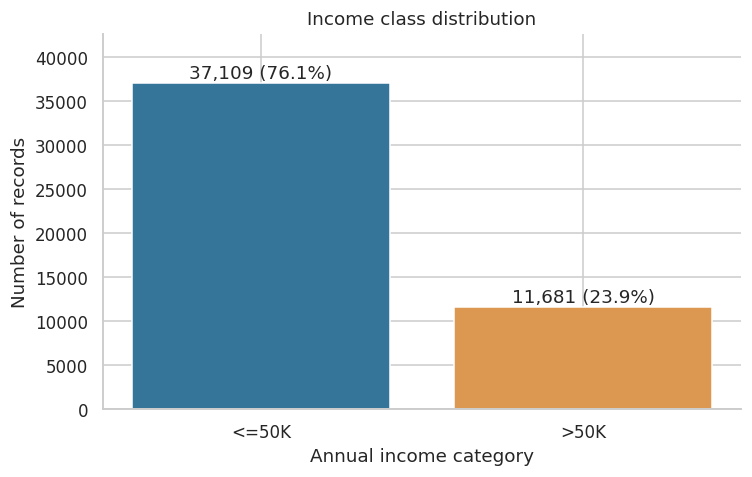

In [7]:
# Chart 2: target class balance
income_counts = df["income"].value_counts().reindex(["<=50K", ">50K"])
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(income_counts.index, income_counts.values, color=["#36759a", "#dc9851"])
for bar, count in zip(bars, income_counts):
    ax.text(bar.get_x() + bar.get_width()/2, count + 450,
            f"{count:,} ({count / len(df):.1%})", ha="center")
ax.set_ylim(0, income_counts.max() * 1.15)
ax.set(title="Income class distribution", xlabel="Annual income category", ylabel="Number of records")
save_chart("02_income_count.png")

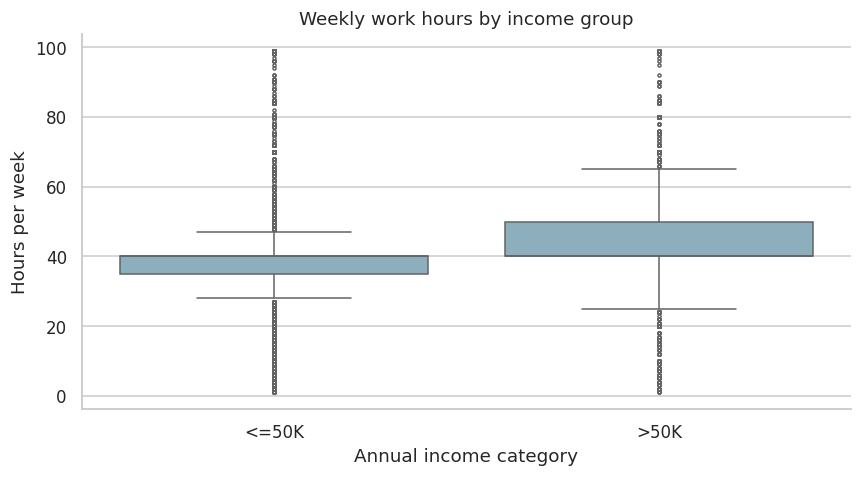

,mean,median,count
income,,,
<=50K,38.84,40.0,37109
>50K,45.45,40.0,11681


In [8]:
# Chart 3: distribution and extremes of working hours by income
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="income", y="hours_per_week", order=["<=50K", ">50K"],
            color="#84b1c5", fliersize=2)
plt.title("Weekly work hours by income group")
plt.xlabel("Annual income category")
plt.ylabel("Hours per week")
save_chart("03_hours_boxplot.png")
hours_summary = df.groupby("income")["hours_per_week"].agg(["mean", "median", "count"])
display(hours_summary.round(2))

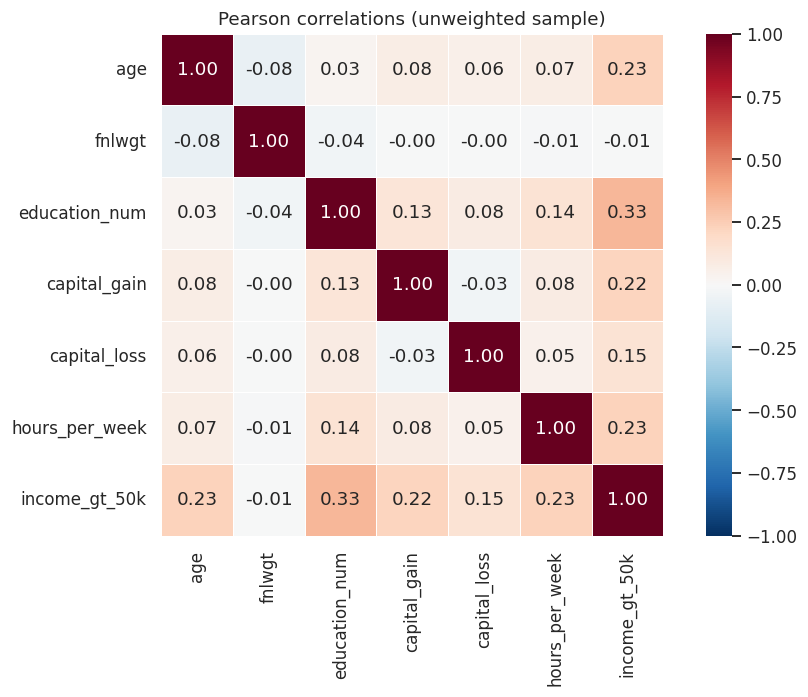

,income_gt_50k
education_num,0.333
age,0.230
hours_per_week,0.228
capital_gain,0.223
capital_loss,0.148
fnlwgt,-0.006


In [9]:
# Chart 4: numeric correlations, including the encoded outcome
corr_columns = numeric_cols + ["income_gt_50k"]
corr = df[corr_columns].corr()
plt.figure(figsize=(9, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5)
plt.title("Pearson correlations (unweighted sample)")
save_chart("04_correlation_heatmap.png")
display(corr["income_gt_50k"].drop("income_gt_50k").sort_values(ascending=False).round(3))

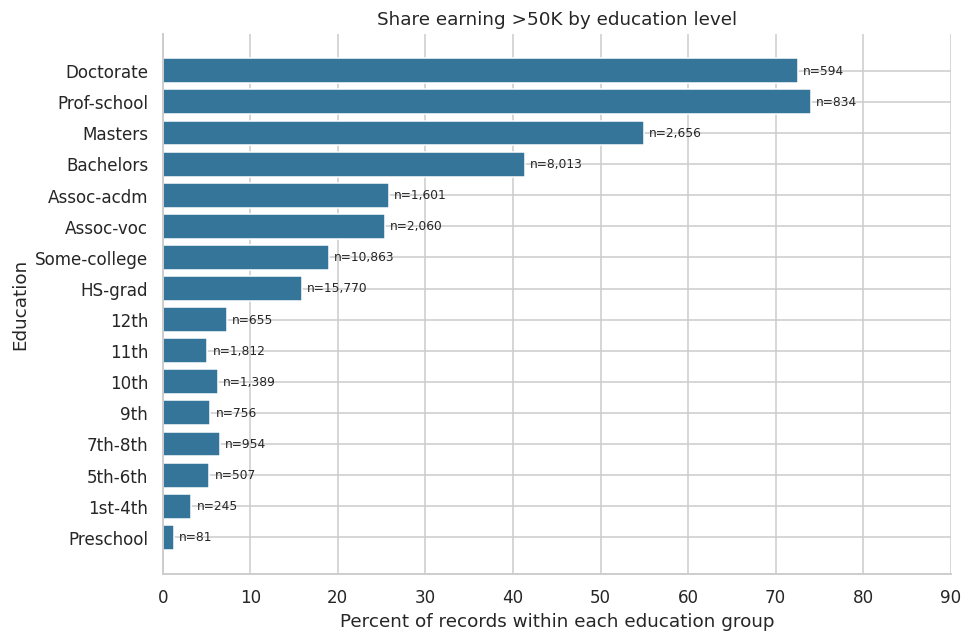

,records,high_income_percent
education,,
Preschool,81,1.23
1st-4th,245,3.27
5th-6th,507,5.33
7th-8th,954,6.50
9th,756,5.42
10th,1389,6.26
11th,1812,5.08
12th,655,7.33
HS-grad,15770,15.86


In [10]:
# Chart 5: compare high-income rates, rather than raw counts, across education groups
education_stats = df.groupby("education").agg(
    records=("income_gt_50k", "size"), high_income_rate=("income_gt_50k", "mean"),
    education_order=("education_num", "first")).sort_values("education_order")
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(education_stats.index, education_stats.high_income_rate * 100, color="#36759a")
for bar, count in zip(bars, education_stats.records):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height()/2,
            f"n={count:,}", va="center", fontsize=8)
ax.set(xlim=(0, 90), title="Share earning >50K by education level",
       xlabel="Percent of records within each education group", ylabel="Education")
save_chart("05_education_income_rate.png")
display(education_stats.assign(high_income_percent=education_stats.high_income_rate * 100)
        [["records", "high_income_percent"]].round(2))

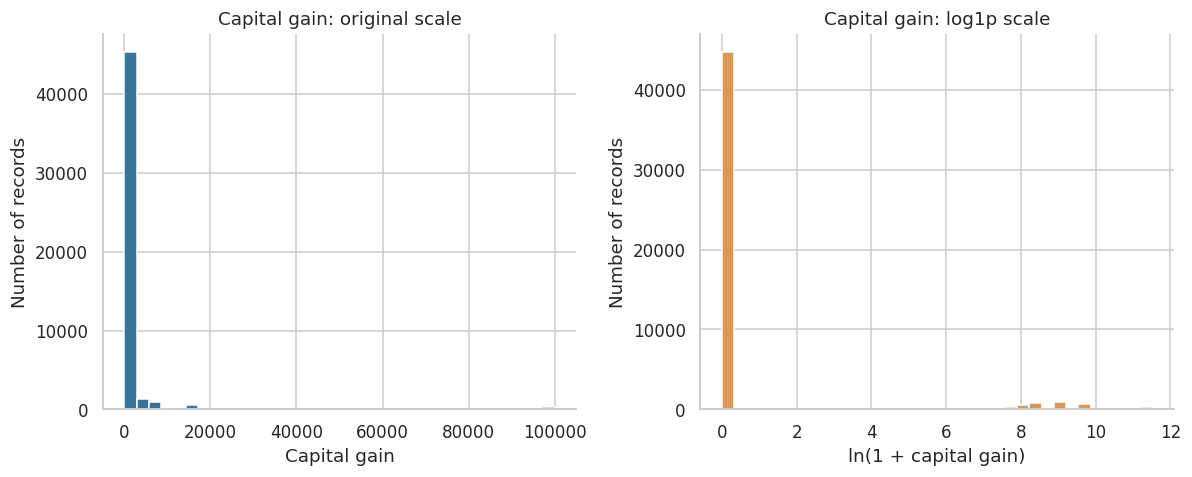

Zero capital gain: 91.73%
Zero capital loss: 95.32%


In [11]:
# Chart 6: capital gains have many zeros and a long positive tail
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(df["capital_gain"], bins=35, color="#36759a")
axes[0].set(title="Capital gain: original scale", xlabel="Capital gain", ylabel="Number of records")
axes[1].hist(np.log1p(df["capital_gain"]), bins=35, color="#dc9851")
axes[1].set(title="Capital gain: log1p scale", xlabel="ln(1 + capital gain)", ylabel="Number of records")
save_chart("06_capital_gain_transform.png")
print(f"Zero capital gain: {df['capital_gain'].eq(0).mean():.2%}")
print(f"Zero capital loss: {df['capital_loss'].eq(0).mean():.2%}")

## 5. Feature engineering

In [12]:
df["age_group"] = pd.cut(df["age"], bins=[16, 29, 44, 59, 100],
                         labels=["17-29", "30-44", "45-59", "60+"])
df["works_overtime"] = (df["hours_per_week"] > 40).astype(int)
df["capital_net"] = df["capital_gain"] - df["capital_loss"]
df["capital_gain_log"] = np.log1p(df["capital_gain"])
df["capital_loss_log"] = np.log1p(df["capital_loss"])
new_features = ["age_group", "works_overtime", "capital_net", "capital_gain_log", "capital_loss_log"]
display(df[["age", "hours_per_week", "capital_gain", "capital_loss"] + new_features].head(10))
display(df.groupby("age_group", observed=True).agg(
    records=("income_gt_50k", "size"), high_income_rate=("income_gt_50k", "mean")).round(3))
assert df[new_features].notna().all().all()
assert set(df["works_overtime"].unique()) <= {0, 1}
assert np.isfinite(df.select_dtypes(include="number").to_numpy()).all()

,age,hours_per_week,capital_gain,capital_loss,age_group,works_overtime,capital_net,capital_gain_log,capital_loss_log
0,25,40,0,0,17-29,0,0,0.000000,0.0
1,38,50,0,0,30-44,1,0,0.000000,0.0
2,28,40,0,0,17-29,0,0,0.000000,0.0
3,44,40,7688,0,30-44,0,7688,8.947546,0.0
4,18,30,0,0,17-29,0,0,0.000000,0.0
5,34,30,0,0,30-44,0,0,0.000000,0.0
6,29,40,0,0,17-29,0,0,0.000000,0.0
7,63,32,3103,0,60+,0,3103,8.040447,0.0
8,24,40,0,0,17-29,0,0,0.000000,0.0
9,55,10,0,0,45-59,0,0,0.000000,0.0


,records,high_income_rate
age_group,,
17-29,14483,0.052
30-44,18674,0.295
45-59,11579,0.383
60+,4054,0.243


## 6. Five key insights

In [13]:
low_share = income_counts["<=50K"] / len(df) * 100
high_share = income_counts[">50K"] / len(df) * 100
hs = education_stats.loc["HS-grad", "high_income_rate"] * 100
ba = education_stats.loc["Bachelors", "high_income_rate"] * 100
edu_corr = corr.loc["education_num", "income_gt_50k"]
gain_rates = df.groupby(df["capital_gain"] > 0)["income_gt_50k"].mean() * 100
insights = [
    f"Data quality: {duplicates_removed:,} duplicate rows were removed, leaving {len(df):,} records. "
    f"Before deduplication, workclass, occupation and native country had "
    f"{missing_before['workclass']:,}, {missing_before['occupation']:,} and {missing_before['native_country']:,} "
    "missing values; these predictor values were retained as Unknown.",
    f"Income is imbalanced: {low_share:.1f}% earn <=50K and {high_share:.1f}% earn >50K. "
    "A future model should be evaluated with precision, recall and F1 as well as accuracy.",
    f"Education is associated with income: {ba:.1f}% of bachelor's graduates earn >50K, "
    f"compared with {hs:.1f}% of high-school graduates. Education code has a correlation of "
    f"{edu_corr:.2f} with the high-income indicator; this is an association, not proof of causation.",
    f"The >50K group works an average of {hours_summary.loc['>50K', 'mean']:.1f} hours weekly, "
    f"versus {hours_summary.loc['<=50K', 'mean']:.1f} hours for the <=50K group. "
    f"Their medians are {hours_summary.loc['>50K', 'median']:.0f} and "
    f"{hours_summary.loc['<=50K', 'median']:.0f} hours, respectively, so the distributions still overlap.",
    f"Capital gain is zero for {df['capital_gain'].eq(0).mean():.1%} of records. "
    f"The >50K rate is {gain_rates.loc[True]:.1f}% with positive gains and "
    f"{gain_rates.loc[False]:.1f}% with zero gains. Log features reduce the long tail; "
    "positive gains should not automatically be deleted as outliers."
]
for finding in insights:
    print("- " + finding + "\n")

- Data quality: 52 duplicate rows were removed, leaving 48,790 records. Before deduplication, workclass, occupation and native country had 2,799, 2,809 and 857 missing values; these predictor values were retained as Unknown.

- Income is imbalanced: 76.1% earn <=50K and 23.9% earn >50K. A future model should be evaluated with precision, recall and F1 as well as accuracy.

- Education is associated with income: 41.3% of bachelor's graduates earn >50K, compared with 15.9% of high-school graduates. Education code has a correlation of 0.33 with the high-income indicator; this is an association, not proof of causation.

- The >50K group works an average of 45.5 hours weekly, versus 38.8 hours for the <=50K group. Their medians are 40 and 40 hours, respectively, so the distributions still overlap.

- Capital gain is zero for 91.7% of records. The >50K rate is 61.7% with positive gains and 20.5% with zero gains. Log features reduce the long tail; positive gains should not automatically be del

- Data quality: 52 duplicate rows were removed, leaving 48,790 records. Before deduplication, workclass, occupation and native country had 2,799, 2,809 and 857 missing values; these predictor values were retained as Unknown.

- Income is imbalanced: 76.1% earn <=50K and 23.9% earn >50K. A future model should be evaluated with precision, recall and F1 as well as accuracy.

- Education is associated with income: 41.3% of bachelor's graduates earn >50K, compared with 15.9% of high-school graduates. Education code has a correlation of 0.33 with the high-income indicator; this is an association, not proof of causation.

- The >50K group works an average of 45.5 hours weekly, versus 38.8 hours for the <=50K group. Their medians are 40 and 40 hours, respectively, so the distributions still overlap.

- Capital gain is zero for 91.7% of records. The >50K rate is 61.7% with positive gains and 20.5% with zero gains. Log features reduce the long tail; positive gains should not automatically be deleted as outliers.

In [14]:
df.to_csv(OUTPUT_DIR / "adult_cleaned_features.csv", index=False)
cleaning_audit.to_csv(OUTPUT_DIR / "cleaning_audit.csv", index=False)
missing_table.to_csv(OUTPUT_DIR / "missing_values_before.csv")
outlier_table.to_csv(OUTPUT_DIR / "outlier_report.csv")
summary_text = "# Five key insights\n\n" + "\n\n".join("- " + s for s in insights) + "\n"
(OUTPUT_DIR / "five_key_insights.md").write_text(summary_text, encoding="utf-8")
print("Final dataset shape:", df.shape)
print("Final missing values:", int(df.isna().sum().sum()))
print("Saved outputs to:", OUTPUT_DIR.resolve())
print("Charts saved:", len(list(CHART_DIR.glob("*.png"))))

Final dataset shape: (48790, 23)
Final missing values: 0
Saved outputs to: /content/outputs
Charts saved: 6
